# UMAP Clustering Visualization of Discriminative Neurons

Simple visualization of discriminative neurons using UMAP dimensionality reduction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Load Data

In [2]:
# Load labels
labels = np.load('../results/activations/labels.npy')

# Load discriminative neurons from all layers
discriminative_neurons = []
neuron_info = []

for layer in range(1, 13):
    # Load neuron stats
    stats = pd.read_csv(f'../results/activations/layer_{layer}_neuron_stats.csv')
    
    # Filter discriminative neurons
    disc_neurons = stats[stats['discriminative'] == True]
    
    if len(disc_neurons) > 0:
        # Load activations
        activations = np.load(f'../results/activations/layer_{layer}_activations.npy')
        
        # Extract discriminative neuron activations
        for idx in disc_neurons['neuron_idx']:
            discriminative_neurons.append(activations[:, idx])
            neuron_info.append({
                'layer': layer,
                'neuron_idx': idx,
                'auc': disc_neurons[disc_neurons['neuron_idx'] == idx]['auc'].values[0],
                'direction': disc_neurons[disc_neurons['neuron_idx'] == idx]['direction'].values[0]
            })

# Stack into matrix (samples x discriminative_neurons)
X_disc = np.column_stack(discriminative_neurons)
neuron_df = pd.DataFrame(neuron_info)

print(f"Total discriminative neurons: {X_disc.shape[1]}")
print(f"Samples: {X_disc.shape[0]}")
print(f"\nNeurons per layer:")
print(neuron_df['layer'].value_counts().sort_index())


Total discriminative neurons: 1350
Samples: 3000

Neurons per layer:
layer
1     128
2     111
3     116
4      83
5      84
6      95
7      84
8      45
9      89
10    164
11    181
12    170
Name: count, dtype: int64


## UMAP Dimensionality Reduction

In [3]:
# Apply UMAP
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=42
)

embedding = reducer.fit_transform(X_disc)
print(f"UMAP embedding shape: {embedding.shape}")

c:\Users\Pawel\anaconda3\envs\human-vs-ai\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (3000, 2)


## Optimal K Selection using Silhouette Score

Evaluating different K values...
------------------------------------------------------------
K=2: Silhouette Score = 0.0855
K=3: Silhouette Score = 0.0733
K=4: Silhouette Score = 0.0772
K=5: Silhouette Score = 0.0749
K=6: Silhouette Score = 0.0656
K=7: Silhouette Score = 0.0664
K=8: Silhouette Score = 0.0589
K=9: Silhouette Score = 0.0604
K=10: Silhouette Score = 0.0560
------------------------------------------------------------
Optimal K: 2 (Silhouette Score: 0.0855)


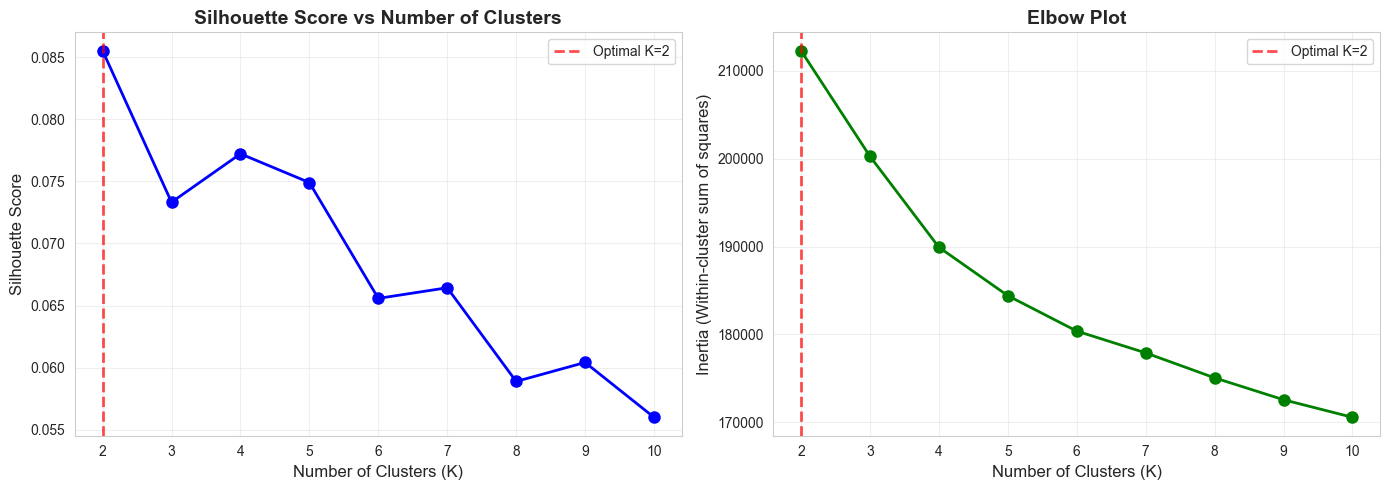


K selection plot saved to results/figures/optimal_k_selection.png


In [4]:
# Test different K values and evaluate using silhouette score
k_range = range(2, 11)  # Test K from 2 to 10
silhouette_scores = []
inertias = []

print("Evaluating different K values...")
print("-" * 60)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_disc)
    
    # Calculate silhouette score
    score = silhouette_score(X_disc, cluster_labels)
    silhouette_scores.append(score)
    inertias.append(kmeans.inertia_)
    
    print(f"K={k}: Silhouette Score = {score:.4f}")

# Find optimal K
optimal_k = k_range[np.argmax(silhouette_scores)]
best_silhouette = max(silhouette_scores)

print("-" * 60)
print(f"Optimal K: {optimal_k} (Silhouette Score: {best_silhouette:.4f})")

# Visualize the scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Silhouette scores
axes[0].plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(optimal_k, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Optimal K={optimal_k}')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Elbow plot (inertia)
axes[1].plot(k_range, inertias, 'go-', linewidth=2, markersize=8)
axes[1].axvline(optimal_k, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Optimal K={optimal_k}')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
axes[1].set_title('Elbow Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/optimal_k_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nK selection plot saved to results/figures/optimal_k_selection.png")


## Final Clustering with Optimal K


In [5]:
# Apply K-means with optimal K
# optimal_k = 3
n_clusters = optimal_k
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_disc)

print(f"Final clustering with K={n_clusters}")
print("=" * 60)
print(f"Cluster distribution:")
for i in range(n_clusters):
    n_samples = np.sum(clusters == i)
    n_ai = np.sum((clusters == i) & (labels == 1))
    n_human = np.sum((clusters == i) & (labels == 0))
    print(f"  Cluster {i}: {n_samples} samples ({n_ai} AI, {n_human} Human)")


Final clustering with K=2
Cluster distribution:
  Cluster 0: 1448 samples (999 AI, 449 Human)
  Cluster 1: 1552 samples (501 AI, 1051 Human)


## UMAP Visualizations


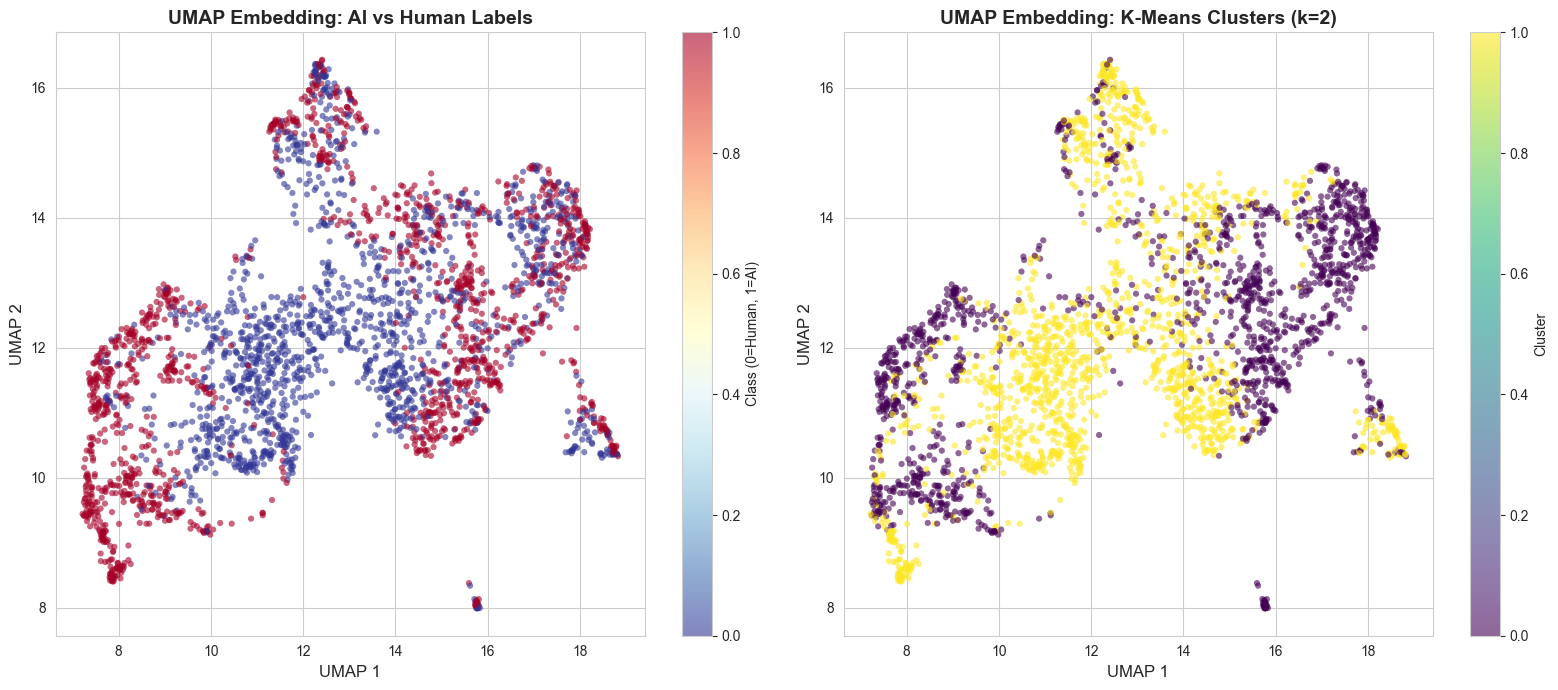

Visualization saved to results/figures/umap_clustering.png


In [6]:
# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Color by true labels (AI vs Human)
scatter1 = axes[0].scatter(
    embedding[:, 0], 
    embedding[:, 1],
    c=labels,
    cmap='RdYlBu_r',
    alpha=0.6,
    s=20,
    edgecolors='none'
)
axes[0].set_title('UMAP Embedding: AI vs Human Labels', fontsize=14, fontweight='bold')
axes[0].set_xlabel('UMAP 1', fontsize=12)
axes[0].set_ylabel('UMAP 2', fontsize=12)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Class (0=Human, 1=AI)', fontsize=10)

# Plot 2: Color by clusters
scatter2 = axes[1].scatter(
    embedding[:, 0], 
    embedding[:, 1],
    c=clusters,
    cmap='viridis',
    alpha=0.6,
    s=20,
    edgecolors='none'
)
axes[1].set_title(f'UMAP Embedding: K-Means Clusters (k={n_clusters})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('UMAP 1', fontsize=12)
axes[1].set_ylabel('UMAP 2', fontsize=12)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Cluster', fontsize=10)

plt.tight_layout()
plt.savefig('../results/figures/umap_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved to results/figures/umap_clustering.png")


## Summary Statistics

In [7]:
# Print summary
print("=" * 60)
print("CLUSTERING SUMMARY")
print("=" * 60)
print(f"\nTotal discriminative neurons: {X_disc.shape[1]}")
print(f"Total samples: {X_disc.shape[0]}")
print(f"Optimal K (based on Silhouette Score): {n_clusters}")
print(f"Silhouette Score: {best_silhouette:.4f}")
print(f"\nCluster Details:")
print("-" * 60)

for i in range(n_clusters):
    mask = clusters == i
    n_total = np.sum(mask)
    n_ai = np.sum((mask) & (labels == 1))
    n_human = np.sum((mask) & (labels == 0))
    ai_pct = n_ai / n_total * 100
    human_pct = n_human / n_total * 100
    
    print(f"\nCluster {i}:")
    print(f"  Total: {n_total} samples")
    print(f"  AI: {n_ai} ({ai_pct:.1f}%)")
    print(f"  Human: {n_human} ({human_pct:.1f}%)")
    
    # Dominant class
    if ai_pct > 60:
        print(f"  → AI-dominant cluster")
    elif human_pct > 60:
        print(f"  → Human-dominant cluster")
    else:
        print(f"  → Mixed cluster")

print("\n" + "=" * 60)


CLUSTERING SUMMARY

Total discriminative neurons: 1350
Total samples: 3000
Optimal K (based on Silhouette Score): 2
Silhouette Score: 0.0855

Cluster Details:
------------------------------------------------------------

Cluster 0:
  Total: 1448 samples
  AI: 999 (69.0%)
  Human: 449 (31.0%)
  → AI-dominant cluster

Cluster 1:
  Total: 1552 samples
  AI: 501 (32.3%)
  Human: 1051 (67.7%)
  → Human-dominant cluster

